In [1]:
    !unzip Chars74K.zip -d /content/Chars74K

Archive:  Chars74K.zip
   creating: /content/Chars74K/Chars74K/
  inflating: /content/Chars74K/Chars74K/KannadaHnd.tgz  
  inflating: /content/Chars74K/Chars74K/KannadaImg.tgz  
  inflating: /content/Chars74K/Chars74K/Lists.tgz  
  inflating: /content/Chars74K/Chars74K/ListsTXT.tgz  


In [2]:
import os

# Create base directory
base_path = "/content/chars74k"
os.makedirs(base_path, exist_ok=True)

# Move tgz files into base_path
!mv /content/Chars/Chars74K/KannadaImg.tgz {base_path}/
!mv /content/Chars/Chars74K/KannadaHnd.tgz {base_path}/
!mv /content/Chars/Chars74K/Lists.tgz {base_path}/
!mv /content/Chars/Chars74K/ListsTXT.tgz {base_path}/


In [3]:
# Extract all archives
!tar -xvzf {base_path}/KannadaImg.tgz -C {base_path}/
!tar -xvzf {base_path}/KannadaHnd.tgz -C {base_path}/
!tar -xvzf {base_path}/Lists.tgz -C {base_path}/
!tar -xvzf {base_path}/ListsTXT.tgz -C {base_path}/


Streaming output truncated to the last 5000 lines.
Kannada/Hnd/Trj/Sample352/
Kannada/Hnd/Trj/Sample352/img352_007.m
Kannada/Hnd/Trj/Sample352/img352_010.m
Kannada/Hnd/Trj/Sample352/img352_014.m
Kannada/Hnd/Trj/Sample352/img352_015.m
Kannada/Hnd/Trj/Sample352/img352_016.m
Kannada/Hnd/Trj/Sample352/img352_017.m
Kannada/Hnd/Trj/Sample352/img352_018.m
Kannada/Hnd/Trj/Sample352/img352_019.m
Kannada/Hnd/Trj/Sample352/img352_020.m
Kannada/Hnd/Trj/Sample352/img352_021.m
Kannada/Hnd/Trj/Sample352/img352_022.m
Kannada/Hnd/Trj/Sample352/img352_023.m
Kannada/Hnd/Trj/Sample352/img352_024.m
Kannada/Hnd/Trj/Sample352/img352_025.m
Kannada/Hnd/Trj/Sample353/
Kannada/Hnd/Trj/Sample353/img353_007.m
Kannada/Hnd/Trj/Sample353/img353_010.m
Kannada/Hnd/Trj/Sample353/img353_014.m
Kannada/Hnd/Trj/Sample353/img353_015.m
Kannada/Hnd/Trj/Sample353/img353_016.m
Kannada/Hnd/Trj/Sample353/img353_017.m
Kannada/Hnd/Trj/Sample353/img353_018.m
Kannada/Hnd/Trj/Sample353/img353_019.m
Kannada/Hnd/Trj/Sample353/img353_020.

In [4]:
for root, dirs, files in os.walk(base_path):
    print(root, "->", len(files), "files")


/content/chars74k -> 12 files
/content/chars74k/Kannada -> 0 files
/content/chars74k/Kannada/Img -> 0 files
/content/chars74k/Kannada/Img/BadImag -> 0 files
/content/chars74k/Kannada/Img/BadImag/Bmp -> 0 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample187 -> 2 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample737 -> 3 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample222 -> 9 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample837 -> 4 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample003 -> 6 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample843 -> 2 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample349 -> 4 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample419 -> 1 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample824 -> 2 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample010 -> 1 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample426 -> 31 files
/content/chars74k/Kannada/Img/BadImag/Bmp/Sample234 -> 1 files
/content/chars74k/Kannada/Img/Bad

In [5]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ======================
# 1. Load dataset lists
# ======================
list_file = "/content/chars74k/Lists/Kannada/Hnd/all.txt"

with open(list_file, "r") as f:
    lines = f.readlines()

# Create dataframe: img_path, label
img_paths = []
labels = []
for line in lines:
    img_paths.append(line.strip())
    # Extract label from folder name "SampleXYZ" → XYZ
    label = int(line.split("/")[1].replace("Sample", ""))
    labels.append(label)

df = pd.DataFrame({"img_path": img_paths, "label": labels})
df["label"] = df["label"] - 1  # shift labels to start at 0

print("Total samples:", len(df))
print("Unique classes:", df["label"].nunique())

# ======================
# 2. Train/Test split
# ======================
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")

# ======================
# 3. Dataset Class
# ======================
class KannadaDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_file = self.dataframe.iloc[idx, 0]
        if not img_file.endswith(".png"):
            img_file += ".png"
        img_path = os.path.join(self.root_dir, img_file)

        image = Image.open(img_path).convert("RGB")
        label = int(self.dataframe.iloc[idx, 1])

        if self.transform:
            image = self.transform(image)
        return image, label

root_dir = "/content/chars74k/Kannada/Hnd"

transform = transforms.Compose([
    transforms.Resize((128, 128)),  # bigger than 64x64
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = KannadaDataset(train_df, root_dir, transform)
test_dataset = KannadaDataset(test_df, root_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Quick check
images, labels = next(iter(train_loader))
print("✅ Batch loaded")
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

# ======================
# 4. Model setup
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Adjust final layer for 657 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 657)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)



Total samples: 16425
Unique classes: 657
Train samples: 13140 | Test samples: 3285
✅ Batch loaded
Images shape: torch.Size([64, 3, 128, 128])
Labels shape: torch.Size([64])
First 10 labels: tensor([574, 347,  30, 314,  17, 461, 322, 173, 233,  22])
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


In [6]:
# ======================
# 5. Training with Mixed Precision + Early Stopping
# ======================
scaler = torch.cuda.amp.GradScaler()
best_acc = 0
patience, patience_counter = 6, 0

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

for epoch in range(50):  # adjust epochs
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/50]", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # Evaluate
    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch [{epoch+1}/50], Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

    # Early stopping
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Model saved (improved)")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⏹ Early stopping triggered.")
            break

print(f"Best Test Accuracy: {best_acc:.2f}%")


/tmp/ipython-input-809799696.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch [1/50]:   0%|          | 0/206 [00:00<?, ?it/s]/tmp/ipython-input-809799696.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/50], Loss: 5.6161, Train Acc: 45.96%, Test Acc: 32.09%
✅ Model saved (improved)


Epoch [2/50], Loss: 2.9441, Train Acc: 88.64%, Test Acc: 76.10%
✅ Model saved (improved)


Epoch [3/50], Loss: 1.2143, Train Acc: 96.49%, Test Acc: 88.68%
✅ Model saved (improved)


Epoch [4/50], Loss: 0.5016, Train Acc: 98.23%, Test Acc: 92.48%
✅ Model saved (improved)


...

Epoch [13/50], Loss: 0.0175, Train Acc: 99.97%, Test Acc: 94.73%


Epoch [14/50], Loss: 0.0142, Train Acc: 99.95%, Test Acc: 94.12%


Epoch [15/50], Loss: 0.0123, Train Acc: 99.97%, Test Acc: 94.37%


Epoch [16/50], Loss: 0.0141, Train Acc: 99.95%, Test Acc: 94.28%


Epoch [17/50], Loss: 0.0132, Train Acc: 99.99%, Test Acc: 94.40%
⏹ Early stopping triggered.
Best Test Accuracy: 94.76%


In [7]:
import json

# ======================
# 7. Build class → Unicode map
# ======================
# Load mapping from JSON file
mapping_file = "class_mapping.json"

id2char = {}
try:
    with open(mapping_file, "r", encoding="utf-8") as f:
        loaded_mapping = json.load(f)
        # Convert keys to integers
        id2char = {int(k): v for k, v in loaded_mapping.items()}
    print(f"✅ Loaded mapping for {len(id2char)} classes")
except FileNotFoundError:
    print("⚠️ Mapping file not found, using placeholder")
    id2char = {i: f"Class_{i+1}" for i in range(657)}

# ======================
# 8. Prediction function
# ======================
def predict_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = outputs.max(1)
        predicted_class = predicted.item()

    # Get character, default to Class_X if not found
    predicted_char = id2char.get(predicted_class, f"Class_{predicted_class+1}")

    # Show image + prediction
    plt.imshow(image)
    plt.axis("off")
    # Use a font that supports Kannada if running locally, otherwise it might show boxes
    plt.title(f"Predicted: {predicted_char}")
    plt.show()

    return predicted_char


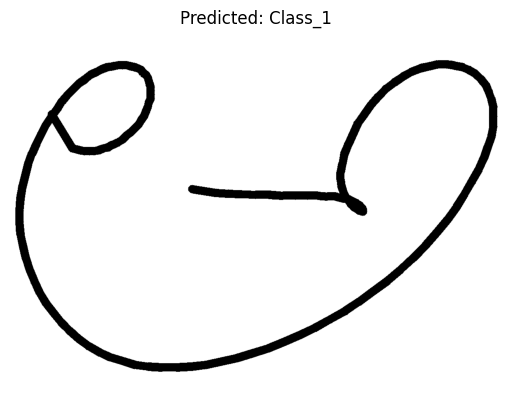

Predicted text: Class_1


In [8]:
result = predict_image("/content/chars74k/Kannada/Hnd/Img/Sample001/img001-001.png")
print("Predicted text:", result)
